<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:58: SyntaxWarning: invalid escape sequence '\$'
<>:58: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3292/1732481604.py:58: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Amount (\$)')


--- Class Imbalance Analysis ---
Normal Transactions (Class 0): 99800 (99.80%)
Fraud Transactions (Class 1) : 200 (0.20%)


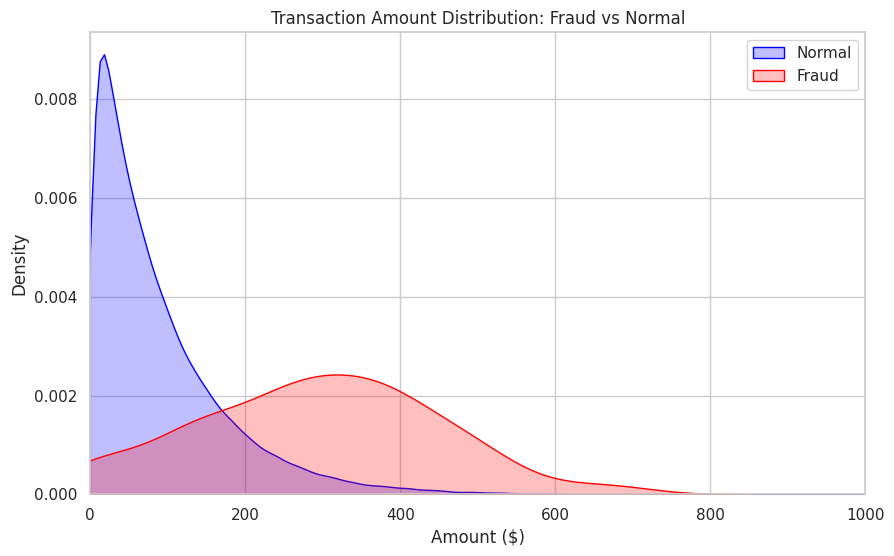

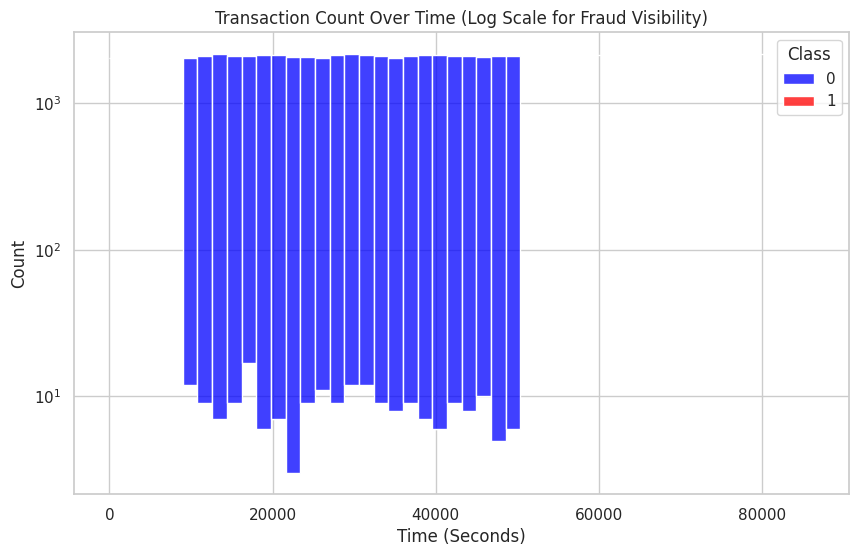


Resampled Training Set Size: 159680 (Class 1 Count: 79840)

================ Logistic Regression Evaluation ================
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96     19960
       Fraud       0.02      0.95      0.05        40

    accuracy                           0.92     20000
   macro avg       0.51      0.94      0.50     20000
weighted avg       1.00      0.92      0.96     20000

Confusion Matrix:
[[18460  1500]
 [    2    38]]

================ Random Forest Evaluation ================
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     19960
       Fraud       0.06      0.90      0.11        40

    accuracy                           0.97     20000
   macro avg       0.53      0.93      0.55     20000
weighted avg       1.00      0.97      0.98     20000

Confusion Matrix:
[[19356   604]
 [    4    36]]


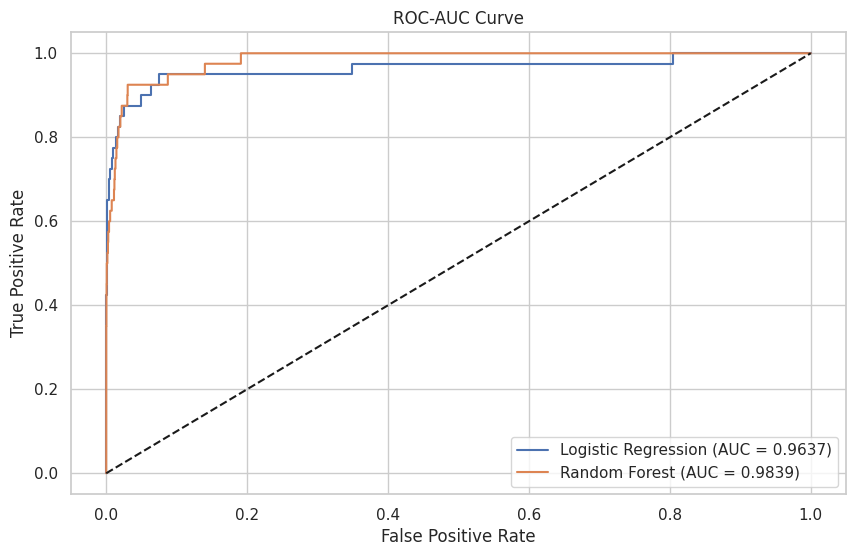


--- Logistic Regression Feature Coefficients ---
Feature  Coefficient
 Amount     0.991076
   Time    -1.007786
     V1    -1.439579

--- Side-by-Side Model Comparison ---
              Model  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression   0.024707    0.95  0.048162 0.963665
      Random Forest   0.056250    0.90  0.105882 0.983907


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

# imbalanced-learn लाइब्रेरी से SMOTE का इम्पोर्ट
from imblearn.over_sampling import SMOTE

# प्लॉट्स की स्टाइलिंग
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# बेंचमार्क क्रेडिट कार्ड फ्रॉड डेटासेट (Kaggle) जैसा डेटा सिमुलेशन
np.random.seed(42)
n_samples = 100000  # 1 लाख ट्रांजैक्शन्स

# फ्रॉड का अनुपात बहुत कम रखना (Heavily Imbalanced - ~0.2%)
fraud_ratio = 0.002
n_fraud = int(n_samples * fraud_ratio)
n_normal = n_samples - n_fraud

# फीचर्स बनाना (Time, Amount, V1-V3 PCA features)
normal_amount = np.random.exponential(scale=90, size=n_normal)
fraud_amount = np.random.normal(loc=300, scale=150, size=n_fraud)
fraud_amount = np.clip(fraud_amount, 1, None) # नेगेटिव अमाउंट हटाना

normal_time = np.random.uniform(0, 86400, n_normal) # 24 घंटे सेकंड्स में
fraud_time = np.random.uniform(10000, 50000, n_fraud)

# PCA जैसी छिपी हुई विशेषताएं (V1, V2, V3)
v1_normal = np.random.normal(0, 1, n_normal)
v1_fraud = np.random.normal(-3, 2, n_fraud)

df_normal = pd.DataFrame({'Time': normal_time, 'Amount': normal_amount, 'V1': v1_normal, 'Class': 0})
df_fraud = pd.DataFrame({'Time': fraud_time, 'Amount': fraud_amount, 'V1': v1_fraud, 'Class': 1})
df = pd.concat([df_normal, df_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)


print("--- Class Imbalance Analysis ---")
counts = df['Class'].value_counts()
percentages = df['Class'].value_counts(normalize=True) * 100
print(f"Normal Transactions (Class 0): {counts[0]} ({percentages[0]:.2f}%)")
print(f"Fraud Transactions (Class 1) : {counts[1]} ({percentages[1]:.2f}%)")

# Transaction Amount Distribution Plot
plt.figure()
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Normal', fill=True, color='blue')
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud', fill=True, color='red')
plt.title('Transaction Amount Distribution: Fraud vs Normal')
plt.xlabel('Amount (\$)')
plt.xlim(0, 1000)
plt.legend()
plt.show()

# Time of Day Analysis Plot
plt.figure()
sns.histplot(data=df, x='Time', hue='Class', bins=48, multiple='stack', palette=['blue', 'red'], log_scale=(False, True))
plt.title('Transaction Count Over Time (Log Scale for Fraud Visibility)')
plt.xlabel('Time (Seconds)')
plt.show()


X = df.drop('Class', axis=1)
y = df['Class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# डेटा स्केलिंग (अमाउंट और टाइम को स्केल करना लॉजिस्टिक रिग्रेशन के लिए जरूरी है)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE लागू करना (केवल ट्रेनिंग डेटा पर, टेस्ट डेटा को अनछुआ रखना है)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nResampled Training Set Size: {len(X_train_resampled)} (Class 1 Count: {sum(y_train_resampled)})")


lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=10, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# मूल्यांकन रिपोर्ट जनरेट करना
models = {'Logistic Regression': (y_pred_lr, y_prob_lr), 'Random Forest': (y_pred_rf, y_prob_rf)}
metrics_summary = []

plt.figure() # ROC Curve के लिए प्लॉट

for name, (preds, probs) in models.items():
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    metrics_summary.append([name, prec, rec, f1, auc])

    print(f"\n================ {name} Evaluation ================")
    print(classification_report(y_test, preds, target_names=['Normal', 'Fraud']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

    # ROC Curve प्लॉटिंग
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC-AUC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


print("\n--- Logistic Regression Feature Coefficients ---")
lr_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)
print(lr_coefs.to_string(index=False))

# 2. Comparison Table
print("\n--- Side-by-Side Model Comparison ---")
summary_df = pd.DataFrame(metrics_summary, columns=['Model', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])
print(summary_df.to_string(index=False))


